In [1]:
from grape import Graph
kg = Graph.from_csv(
	directed=False,
	node_type_path="kg_data/directus/node_classes.csv",
	node_path="kg_data/directus/nodes.csv",
	nodes_column="node_id",
	node_types_separator="|",
	node_list_node_types_column="class_names",
	edge_type_path="kg_data/directus/edge_classes.csv",
	edge_path="kg_data/directus/edges.csv",
	sources_column="source",
	destinations_column="destination",
	edge_list_edge_types_column="edge_class",
	name="EMI/Directus KG",
)

In [2]:
kg_main_component = kg.remove_components(top_k_components=1)

In [3]:
kg_main_component

<div class="graph-report"><style>.graph-report li {margin: 0.5em 0 0.5em 0;}.graph-report .paragraph {text-align: justify;word-break: break-all;}.graph-report .small-columns {column-count: 4;column-gap: 2em;}.graph-report .medium-columns {column-count: 3;column-gap: 2em;}.graph-report .large-columns {column-count: 2;column-gap: 2em;}.graph-report .single-column {}@media only screen and (max-width: 600px) {.graph-report .small-columns {column-count: 1;}.graph-report .medium-columns {column-count: 1;}.graph-report .large-columns {column-count: 1;}}@media only screen and (min-width: 600px) and (max-width: 800px) {.graph-report .small-columns {column-count: 2;}.graph-report .medium-columns {column-count: 1;}.graph-report .large-columns {column-count: 1;}}@media only screen and (min-width: 800px) and (max-width: 1024px) {.graph-report .small-columns {column-count: 3;}.graph-report .medium-columns {column-count: 2;}.graph-report .large-columns {column-count: 1;}}</style><h2>EMI/Directus KG</h2><p class="paragraph">The undirected multigraph EMI/Directus KG has 56.71K heterogeneous nodes and 213.07K heterogeneous edges. The graph is connected, that is, it is composed of a single connected component that includes all nodes and edges. The RAM requirements for the nodes and edges data structures are 8.38MB and 2.16MB respectively.</p><h3 style="margin: 1em 0 0 0;">Degree centrality</h3><p class="paragraph">The minimum node degree is 1, the maximum node degree is 37.68K, the mode degree is 5, the mean degree is 7.51 and the node degree median is 5.</p><p class="paragraph">The nodes with the highest degree centrality are public.directus_users(053e0368-4ed8-4569-a070-81a22ad13957) (degree 37.68K and node type public.directus_users), public.directus_users(b57ab753-5356-4005-919a-cbc18a0bc0de) (degree 34.14K and node type public.directus_users), public.Container_Models(1) (degree 11.02K and node type public.Container_Models), public.Container_Models(5) (degree 8.06K and node type public.Container_Models) and public.SI_Units(18) (degree 7.83K and node type public.SI_Units).</p><h3 style="margin: 1em 0 0 0;">Node types</h3><p class="paragraph">The graph has 31 node types, of which the 10 most common are public.Containers (26.08K nodes, 45.99%), public.Dried_Samples_Data (9.59K nodes, 16.91%), public.Field_Data (8.72K nodes, 15.37%), public.Extraction_Data (6.13K nodes, 10.81%), public.MS_Data (3.18K nodes, 5.61%), public.Aliquoting_Data (2.54K nodes, 4.48%), public.directus_permissions (110 nodes, 0.19%), public.directus_presets (107 nodes, 0.19%), public.Batches (77 nodes, 0.14%) and public.SI_Units (37 nodes, 0.07%). The RAM requirement for the node types data structure is 2.95MB.</p><h4 style="margin: 1em 0 0 0;">Singleton node types</h4><p class="paragraph">Singleton node types are node types that are assigned exclusively to a single node, making the node type relatively meaningless, as it adds no more information than the node name itself. The graph contains a singleton node type, which is public.directus_sessions (node public.directus_sessions(Bq-A3OyNqvNCFOFNJ0718Z5CfSWc-jOzwLqriKbECgjncw3XsfDHM4rYjeDQkWuf) (degree 1 and node type public.directus_sessions)).</p><h3 style="margin: 1em 0 0 0;">Edge types</h3><p class="paragraph">The graph has 96 edge types, of which the 10 most common are public.Containers(user_created) (52.16K edges, 12.24%), public.Containers(container_model) (38.04K edges, 8.93%), public.Containers(user_updated) (23.34K edges, 5.48%), public.Dried_Samples_Data(sample_container) (19.17K edges, 4.50%), public.Dried_Samples_Data(user_created) (19.17K edges, 4.50%), public.Dried_Samples_Data(parent_container) (19.14K edges, 4.49%), public.Field_Data(user_created) (17.44K edges, 4.09%), public.Field_Data(user_updated) (17.26K edges, 4.05%), public.Dried_Samples_Data(user_updated) (14.88K edges, 3.49%) and public.Dried_Samples_Data(field_data) (14.02K edges, 3.29%). The RAM requirement for the edge types data structure is 1.7

In [4]:
from grape.embedders import Node2VecSkipGramEnsmallen
embedding = Node2VecSkipGramEnsmallen().fit_transform(kg_main_component)
node, context = embedding.get_all_node_embedding()

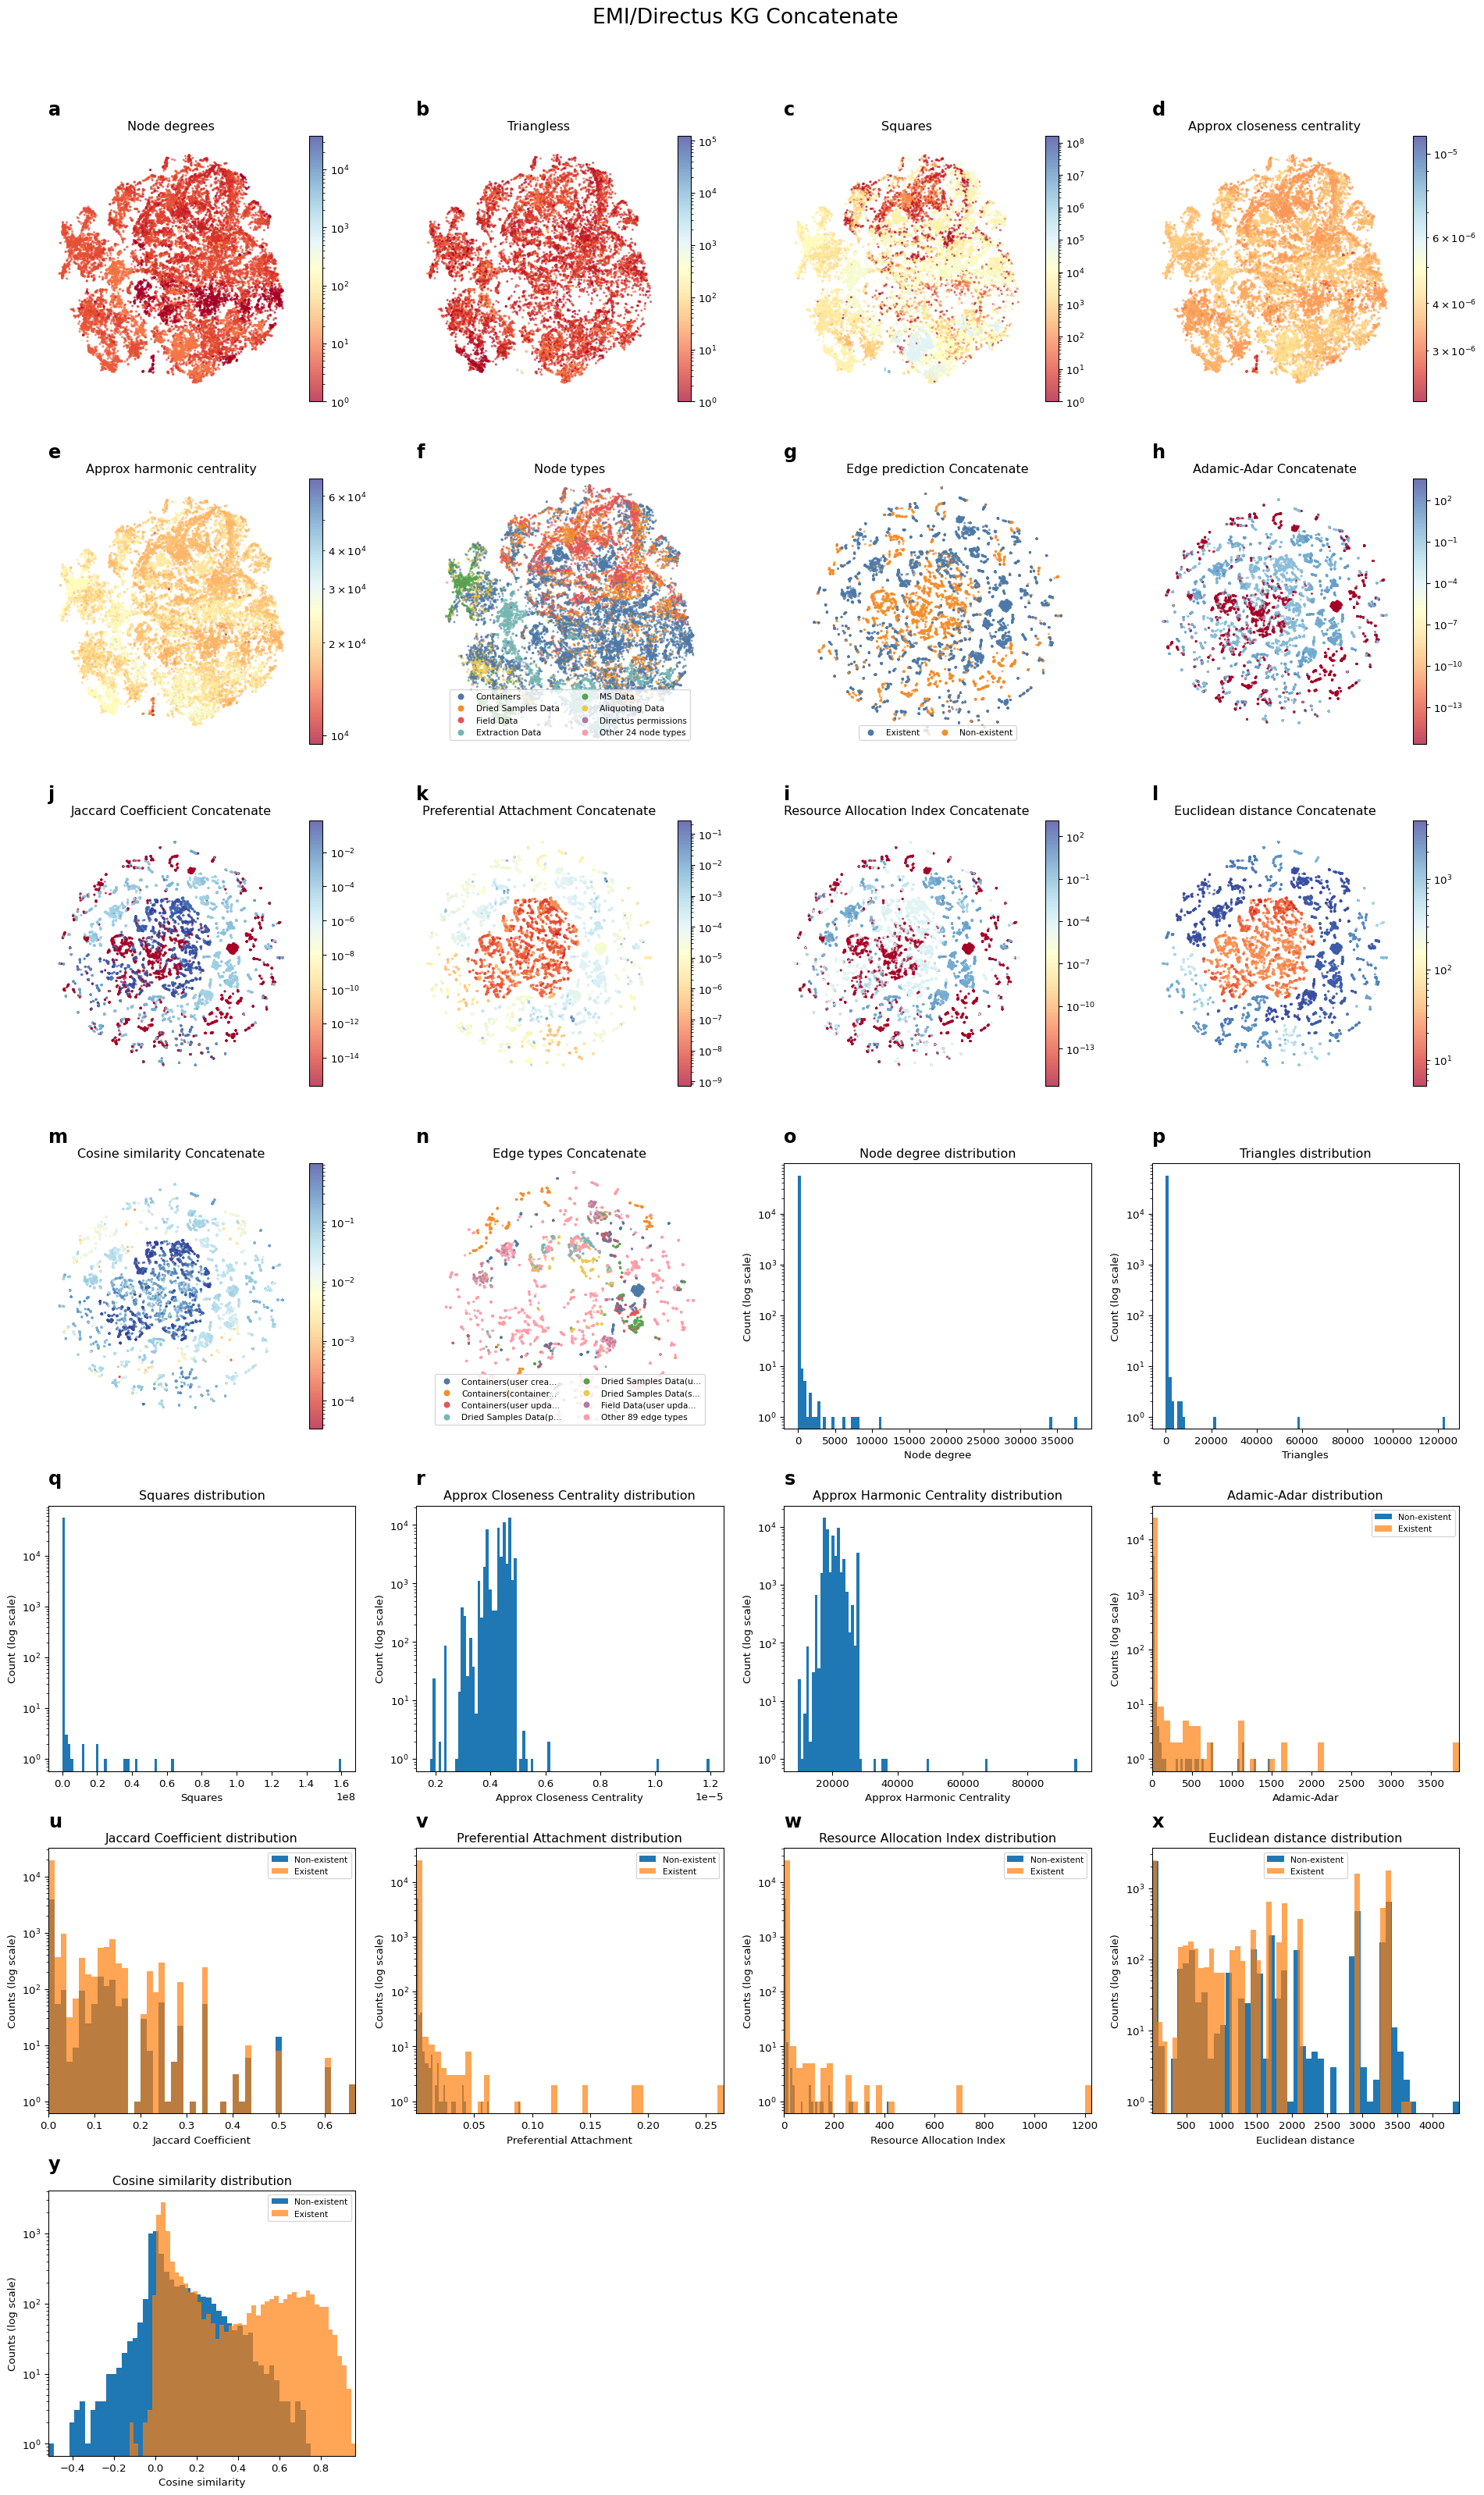

In [5]:
from grape import GraphVisualizer

GraphVisualizer(
	kg_main_component,
	#verbose=True,
	#n_components=4,
    #rotate=True,
).fit_and_plot_all(embedding)